# JWST Modeling WFE Oscillations from IEC heaters

On short timescales (a few minutes) the dominant source of WFE variations in JWST has been found to be a semi-periodic oscillation in astigmatism, which is now understood to be driven by heater resistors in the Instrument Electronics Compartment (IEC). This behavior was first identified in preflight testing at NASA's Johnson Space Center, and further characterized in flight. See [Telfer et al. 2024](https://www.spiedigitallibrary.org/conference-proceedings-of-spie/13092/3020273/Empirical-characterization-of-JWST-wavefront-error-variations/10.1117/12.3020273.short) for measurements and analyses. Briefly, thermostats cycle on and off periodically to keep the instrument control electronics boards in their operating temperatures, and differential thermal expansion and contraction exert tiny forces on the back of the OTE, enough to slightly affect its shape. 

This effect is small (typically 1-2 nm rms of astigmatism), and since the characteristic timescale is ~3 minutes, the time-averaged effect becomes even smaller in longer-duration observations. For the majority of datasets the impact of this effect on PSFs is negligible. However, some especially sensitive observations, such as transiting time series observations and coronagraphy, may under some circumstances be measurably affected by the IEC oscillations. 

STPSF therefore can retrieve the relevant IEC board temperatures from MAST, and use those to produce a model for amplitude and variation of this effect over time. This can be used to generate suitable time-variable PSFs, or alternatively the temperature telemetry itself may be used as ancillary data for de-correlating science observations. 

This notebook demonstrates how to retrieve IEC temperature measurements and IEC WFE models and use them in PSF calculations.  

<div class="alert alert-block alert-info">
This is an *advanced, subtle* topic in PSF modeling. It is not relevant for the large majority of science datasets.
</div>

In [1]:
import numpy as np
import stpsf
import matplotlib, matplotlib.pylab as plt
import astropy.time, astropy.units

## Retrieve IEC temperature data and WFE model

The function `estimate_iec_induced_wfe_at_time` in `stpsf.opds` retrieves the temperatures from MAST and uses them to create an interpolated model for the WFE as a function of time. The model implemented follows the mathematical framework described in Telfer et al. 2024: a weighted sum of time-lagged versions of the 5 dominant thermostat heaters. 

This function takes a time as input, and returns a WFE amplitude value in SI units of nanometers rms. 

In [2]:
stpsf.opds.estimate_iec_induced_wfe_at_time('2022-07-10T16:00:00')

array(1.09422935)

The function can optionally produce a diagnostic plot that shows the temperature data and their weighted sum. This can be interesting to look at and may help develop understanding of what's going on, but is kind of technical:

array(1.09422935)

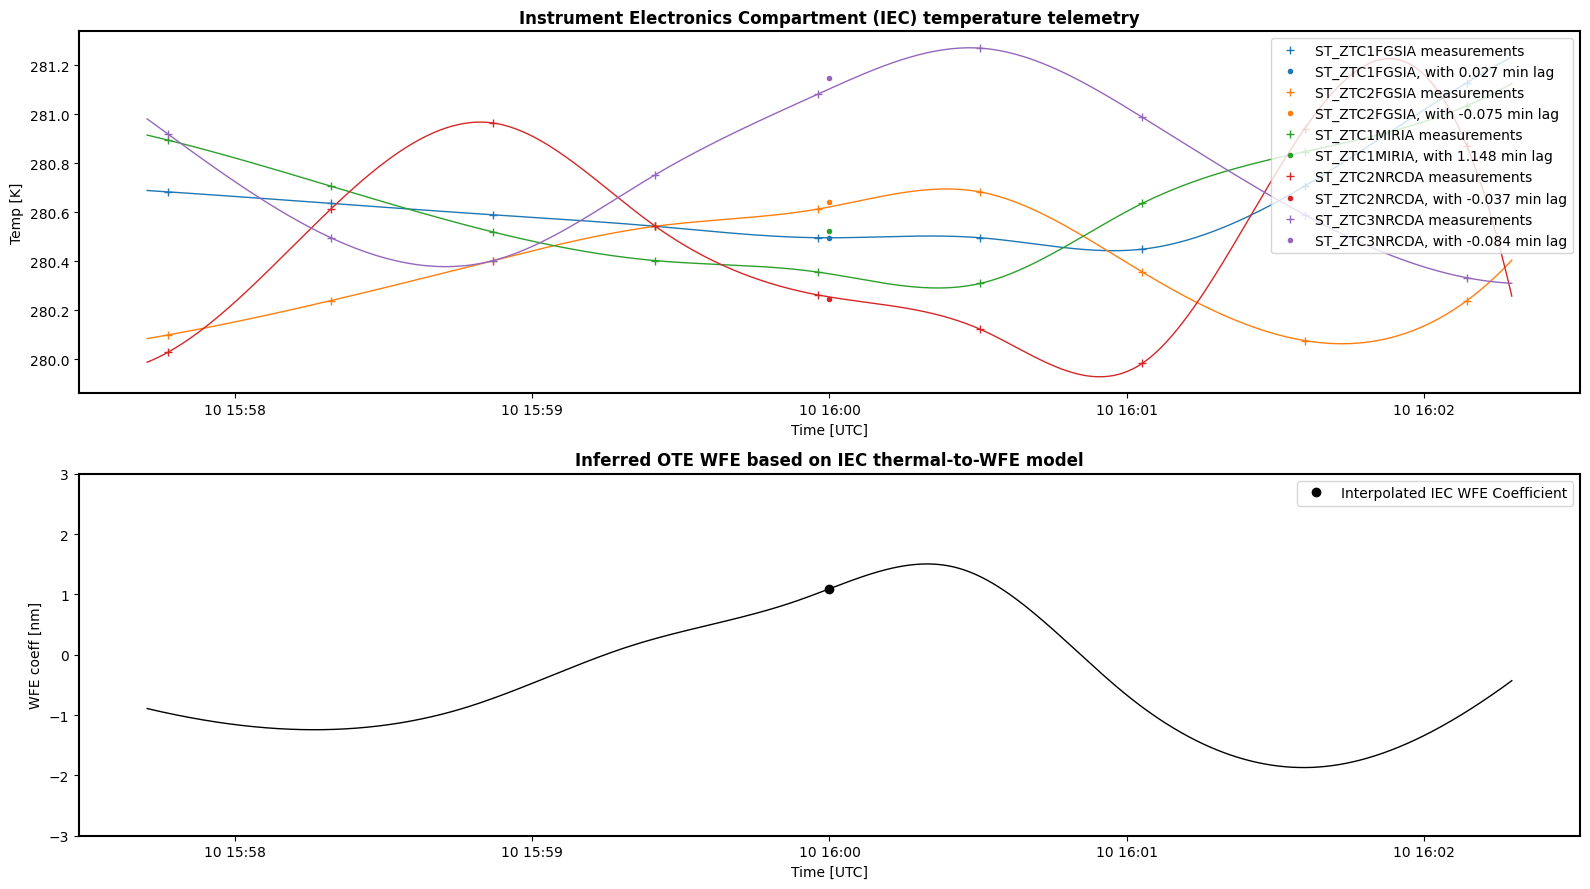

In [3]:
stpsf.opds.estimate_iec_induced_wfe_at_time('2022-07-10T16:00:00', plot=True)

We can also retrieve WFE over a range of times at once by providing an array of times. 

Let's define some time range of interest. This example range happens to be during part of a transiting exoplanet observation using NIRISS, in ERS program 1366 observation 4.  Over the course of an hour, you can see the amplitude vary up and down as the various heaters beat together in and out of phase:

In [4]:
tstart = astropy.time.Time('2022-07-10T16:00:00')

trange = tstart + np.arange(60) * astropy.units.minute

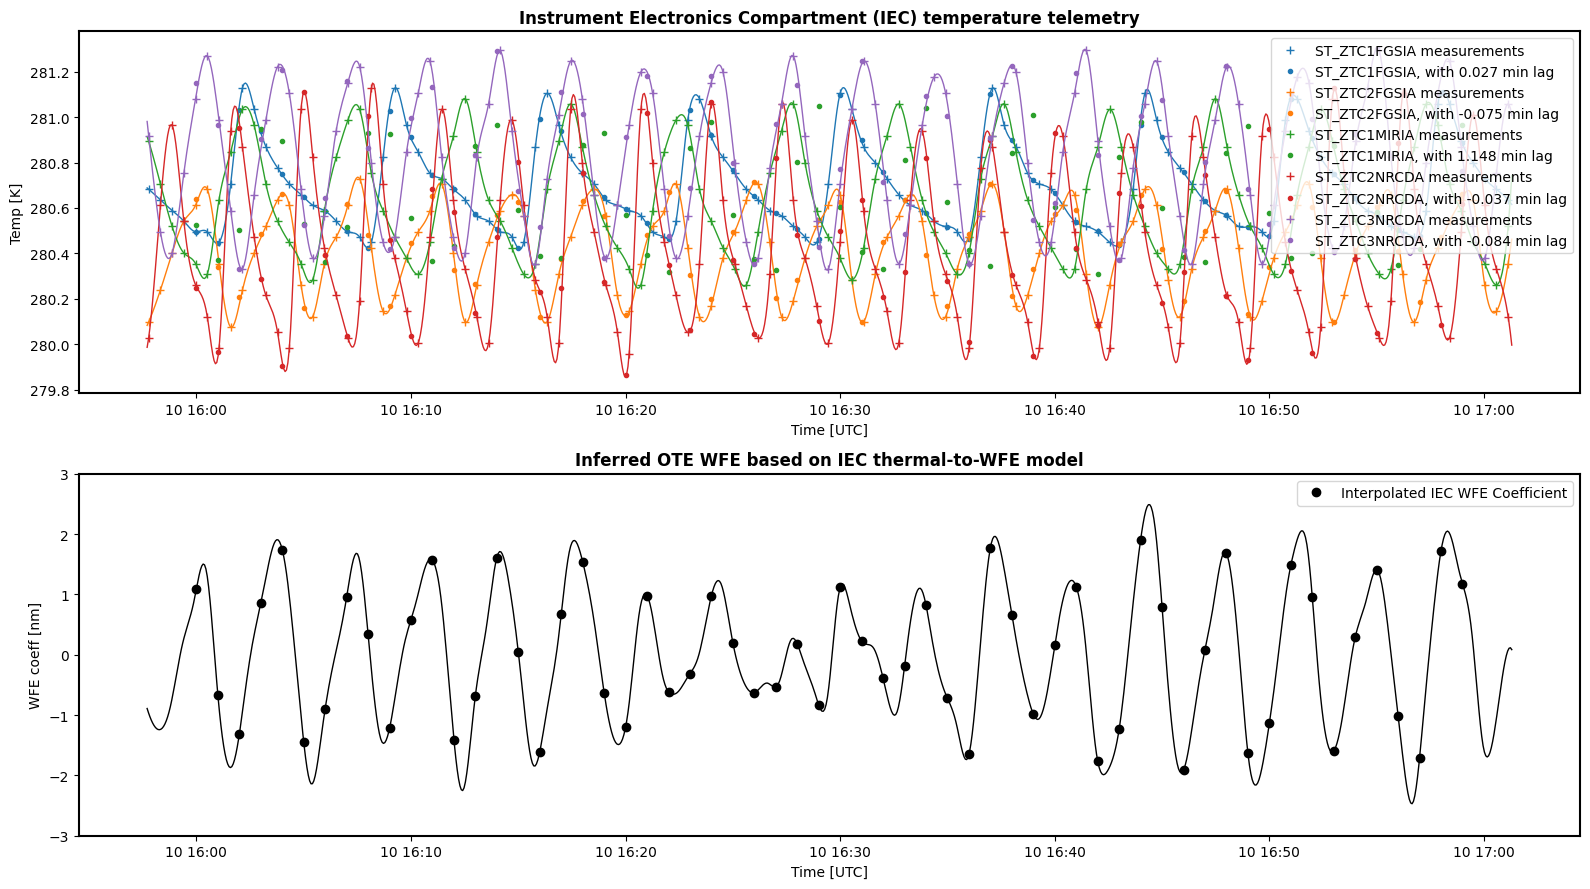

In [5]:
iec_wfe_coeffs = stpsf.opds.estimate_iec_induced_wfe_at_time(trange, plot=True)

## Using the IEC WFE in PSF calculations

To use this WFE in PSF calculations, we first retrieve an OTE object using `enable_adjustable_ote` so we can simulate mirror motions, and then we use its `apply_iec_drift` method to set an IEC drift amplitude, and then calculate the PSF as usual. 

In this case we simulate a NIRSpec PSF using the S1600A1 BOTS aperture, again based on obs 1366:1 as above. 

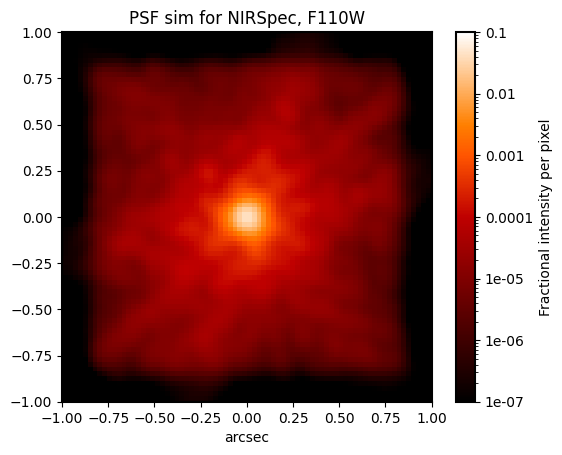

In [6]:
# Create an STPSF instrument object and configure it as desired
nrs = stpsf.NIRSpec()
nrs.image_mask = 'S1600A1' # BOTS aperture
wavelen = 1*astropy.units.micron

# Enable simulation of OTE wavefront variations. This will return an OTE object linked with your instrument object.
nrs, ote = stpsf.enable_adjustable_ote(nrs)

# apply some IEC drift value. Here notionally 1 nm rms just for example.
ote.apply_iec_drift(1)

nrs_psf = nrs.calc_psf(monochromatic=wavelen)

stpsf.display_psf(nrs_psf, ext='OVERDIST', imagecrop=2)

Let's take a closer look, and compare before and after to see how much the wavefront changes between time steps in the above time series, and how much the PSF changes as a result.

In [7]:
# Create an STPSF instrument object and configure it as desired
nrs = stpsf.NIRSpec()
nrs.image_mask = 'S1600A1' # BOTS aperture
wavelen = 1*astropy.units.micron

# Enable simulation of OTE wavefront variations. This will return an OTE object linked with your instrument object.
nrs, ote = stpsf.enable_adjustable_ote(nrs)

# We're going to get OPDs and compute PSFs for the first two time steps in the time series above.
opds = []
psfs = []

for i in range(2):
    # Apply the WFE driff coefficient
    ote.apply_iec_drift(iec_wfe_coeffs[i])

    # Save OPD and PSF
    opds.append(ote.opd.copy())
    psfs.append(nrs.calc_psf(monochromatic=wavelen))


Text(0.5, 1.0, 'Delta OPD between first 2 time steps\nIEC WFE coeffs: 1.094, -1.317 nm')

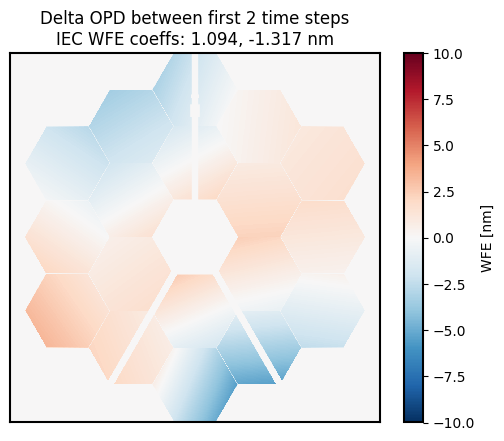

In [8]:
# Now let's plot the delta OPD

plt.imshow((opds[1] - opds[0])*ote.amplitude*1e9, 
           cmap = matplotlib.cm.RdBu_r, vmin=-10, vmax=10)
plt.gca().axes.xaxis.set_visible(False)
plt.gca().axes.yaxis.set_visible(False)
plt.colorbar(label='WFE [nm]')
plt.title(f"Delta OPD between first 2 time steps\nIEC WFE coeffs: {iec_wfe_coeffs[0]:.3f}, {iec_wfe_coeffs[2]:.3f} nm")

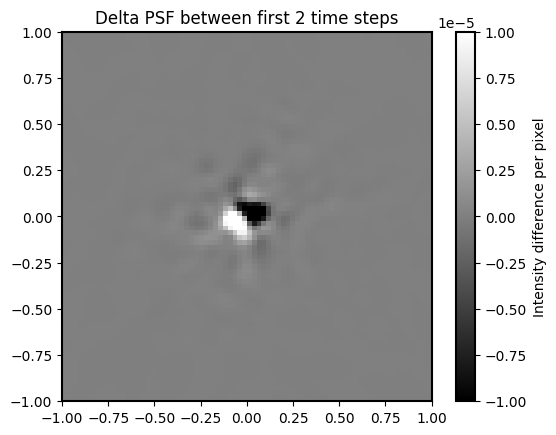

In [9]:
stpsf.display_psf_difference(psfs[1], psfs[0], ext1='OVERDIST', ext2='OVERDIST', 
                             title='Delta PSF between first 2 time steps',
                             vmax=1e-5, imagecrop=2)

Thus we see there is a small, but nonzero, difference between the simulated PSFs due to the ~ 2 nm of differential aberration due to the IEC oscillation. 